# 09. モデル検証と実務応用 — 信じる前に疑い、分布のまま決める

## この章で分かること

- **事前予測チェック / 事後予測チェック (PPC)**: モデルがデータを語れているか
- **LOO-CV**(と WAIC)によるモデル比較 — 「正しいモデル選び」ではなく **予測性能** を見る
- **ベイズファクター** の概要と注意点
- 実務応用 5 連発: A/B テストの期待損失・株式リターン・ワイン品質ランキング・
  ポーカーの相手レンジ・LLM 評価スコア

```{admonition} 核心 — ひとことで
:class: tip
**「信じる前に疑う」：事前予測チェックで事前の常識を、事後予測チェックでデータ再現性を検査する。**
モデル比較は当てはまり（訓練誤差）でなく**予測性能（LOO-CV）**で。ベイズファクターは事前への敏感さに注意（Lindley）。
実務の決め手は「事後分布 → 確率・期待損失・信用区間つきランキング」に変換し、そのまま意思決定すること。
```

In [1]:
# Setup (PyMC is used only in the LOO section; everything else is closed-form).
import os

os.environ.setdefault("PYTENSOR_FLAGS", "cxx=,mode=NUMBA")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.io as pio
from scipy import stats

from bayes_textbook import visualization as viz
from bayes_textbook.conjugacy import BetaBinomial, NormalNormal
from bayes_textbook.models import fit_partial_pooling_normal
from bayes_textbook.simulation import (
    make_ab_test_data, make_returns, make_wine_ratings, prob_a_beats_b,
)

pio.renderers.default = "plotly_mimetype+notebook_connected"
rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

try:
    import arviz as az
    import pymc as pm

    PYMC_OK = True
except Exception as err:  # noqa: BLE001
    PYMC_OK = False
    print(f"PyMC unavailable ({type(err).__name__}) -> the LOO section will be skipped")

## 1. 事前予測チェック — モデルを動かす前の健全性検査

事前分布から $\theta$ を引き、そのままデータを生成してみる:

$$
p(x) = \int p(x \mid \theta)\, p(\theta)\, d\theta
$$

生成されたデータが「あり得る範囲」に散らばっていれば、事前は妥当。
桁違いの値ばかり出るなら、事前がおかしい — **データを 1 つも使わずに** モデルの欠陥を見つけられます。

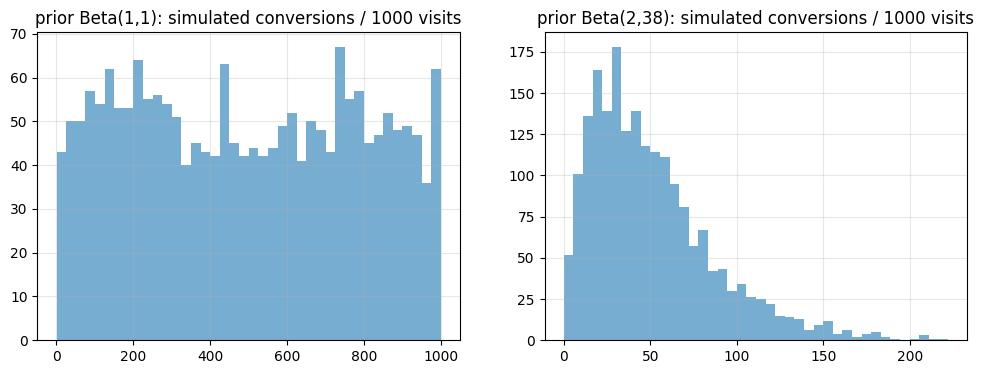

Beta(1,1) says 'CVR 70% is as likely as 5%' -> absurd for e-commerce.
Beta(2,38) (mean 5%) generates data in a realistic range.


In [2]:
# Prior predictive check: would this prior generate sane CVR data?
n_visits = 1000
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (a, b) in zip(axes, [(1, 1), (2, 38)], strict=True):
    thetas = stats.beta(a, b).rvs(2000, random_state=np.random.default_rng(0))
    fake_conversions = np.random.default_rng(1).binomial(n_visits, thetas)
    ax.hist(fake_conversions, bins=40, alpha=0.6)
    ax.set_title(f"prior Beta({a},{b}): simulated conversions / 1000 visits")
    ax.grid(alpha=0.3)
plt.show()
print("Beta(1,1) says 'CVR 70% is as likely as 5%' -> absurd for e-commerce.")
print("Beta(2,38) (mean 5%) generates data in a realistic range.")

## 2. 事後予測チェック — 学習後の答え合わせ

事後から $\theta$ を引いてデータを再生成し、実データと比べます。
わざと **間違ったモデル**(過分散のあるカウントデータに Poisson)を当てて、
PPC が問題を検出する様子を見ます。

data: mean=7.0, var=22.1  (Poisson would force var=mean)


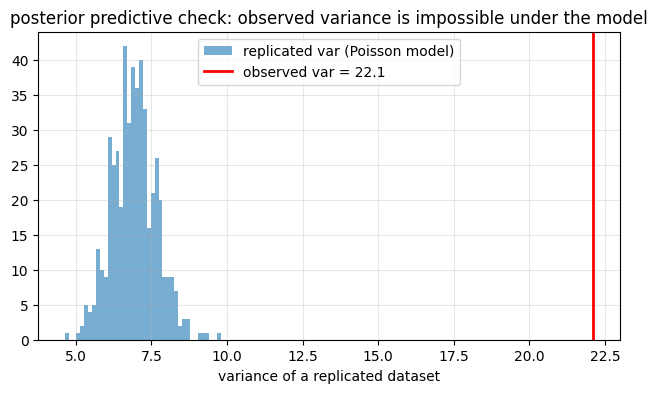

In [3]:
# PPC catches overdispersion: Poisson model vs negative-binomial-ish data.
true_counts = np.random.default_rng(7).negative_binomial(3, 0.3, size=200)  # var >> mean
print(f"data: mean={true_counts.mean():.1f}, var={true_counts.var():.1f}  (Poisson would force var=mean)")

# Fit Gamma-Poisson posterior for the rate, then simulate replicated datasets.
from bayes_textbook.conjugacy import GammaPoisson

post_rate = GammaPoisson(1, 0.1).update(int(true_counts.sum()), len(true_counts))
r = np.random.default_rng(8)
rep_vars = []
for _ in range(500):
    lam = post_rate.dist.rvs(random_state=r)
    rep = r.poisson(lam, size=len(true_counts))
    rep_vars.append(rep.var())

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(rep_vars, bins=40, alpha=0.6, label="replicated var (Poisson model)")
ax.axvline(true_counts.var(), color="r", lw=2, label=f"observed var = {true_counts.var():.1f}")
ax.set_xlabel("variance of a replicated dataset")
ax.set_title("posterior predictive check: observed variance is impossible under the model")
ax.grid(alpha=0.3); ax.legend()
plt.show()

観測された分散は、モデルが生成し得る分散の分布から完全に外れています —
**このモデルはデータの散らばりを語れていない**(負の二項などへ修正すべき)。
検定統計量(ここでは分散)を変えれば、裾・ゼロ過剰など任意の側面を検査できます。

## 3. モデル比較 — LOO-CV(と WAIC)

「どちらのモデルが良いか」は **将来データへの予測性能** で比べるのがベイズの実務です。

- **LOO-CV**: 1 点抜き交差検証の近似(PSIS-LOO)。現在の標準
- **WAIC**: 同じ目標の情報量規準。LOO とほぼ同じ答えになるため、
  ArviZ 1.x では LOO に一本化されました(本書も LOO を使います)

直線データに「直線モデル」と「3 次モデル」を当て、LOO で比較します。
見どころ: 3 次モデルは **当てはまり(訓練誤差)では必ず勝つ** のに、
LOO ではその優位が消えます(差は標準誤差の範囲の引き分けに落ちる)。

In [4]:
# LOO comparison: linear vs cubic on truly-linear data.
x_cmp = np.sort(np.random.default_rng(2).uniform(-2, 2, 40))
y_cmp = 1.0 + 0.8 * x_cmp + 0.6 * np.random.default_rng(3).standard_normal(40)

if PYMC_OK:
    idatas = {}
    for name, degree in [("linear", 1), ("cubic", 3)]:
        with pm.Model() as m:
            ws = [pm.Normal(f"w{d}", 0, 5) for d in range(degree + 1)]
            mu = sum(w * x_cmp**d for d, w in enumerate(ws))
            sigma = pm.HalfNormal("sigma", 2)
            pm.Normal("y", mu, sigma, observed=y_cmp)
            idata = pm.sample(draws=500, tune=500, chains=2, cores=1,
                              random_seed=42, progressbar=False)
            pm.compute_log_likelihood(idata, progressbar=False)
        idatas[name] = idata

    # In-sample fit: the cubic ALWAYS wins this one (more knobs, less residual).
    for deg in [1, 3]:
        resid = y_cmp - np.polyval(np.polyfit(x_cmp, y_cmp, deg), x_cmp)
        print(f"in-sample residual sd (degree {deg}): {resid.std():.4f}")
    print()
    comparison = az.compare({k: v for k, v in idatas.items()}, var_name="y")
    print(comparison.to_string())
else:
    print("[skipped: PyMC not available] On linear data, LOO shows no gain for the cubic.")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [w0, w1, sigma]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

NUTS: [w0, w1, w2, w3, sigma]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


in-sample residual sd (degree 1): 0.6962
in-sample residual sd (degree 3): 0.6565

        rank  elpd    p  elpd_diff  weight   se  dse  warning
cubic      0 -50.0  6.0        0.0    0.54  6.8  0.0     True
linear     1 -50.0  4.0       -0.0    0.46  5.9  2.2    False


/home/kazumasa/projects/.venv/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.67 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


in-sample では 3 次が必ず勝ちますが、LOO の `elpd` は両者ほぼ同点
(`elpd_diff` は標準誤差 `dse` の範囲内)で、余計な 2 つの係数に **予測上の見返りはゼロ**
と判定されます。これが「当てはまりではなく予測性能で比べる」の実演です。
なお `warning=True`(Pareto-k 警告)が出たら近似が怪しいサイン(§9)。

### ベイズファクターの概要

モデル比較のもう一つの道具が **ベイズファクター** $BF_{10} = p(x \mid M_1)/p(x \mid M_0)$
(周辺尤度の比)。共役モデルなら閉形式で計算できます。
ただし **事前分布に極めて敏感** で、漠然とした事前を使うと単純なモデルが
自動的に勝ってしまう(Lindley のパラドックス)ため、
実務では「予測性能(LOO)+ ドメイン判断」が推奨です。

In [5]:
# Bayes factor for a coin: point null (theta = 0.5) vs Beta(1,1) alternative.
s, n = 60, 100

# Marginal likelihood under H0: theta fixed at 0.5.
ml_h0 = stats.binom.pmf(s, n, 0.5)
# Under H1: integral of binomial over Beta(1,1) prior = Beta-Binomial marginal.
ml_h1 = stats.betabinom.pmf(s, n, 1, 1)
bf10 = ml_h1 / ml_h0
print(f"data: {s}/100 heads")
print(f"marginal likelihoods: H0={ml_h0:.5f}, H1={ml_h1:.5f}")
print(f"Bayes factor BF10 = {bf10:.2f}  ({'weak' if bf10 < 3 else 'noteworthy'} evidence vs a fair coin)")

data: 60/100 heads
marginal likelihoods: H0=0.01084, H1=0.00990
Bayes factor BF10 = 0.91  (weak evidence vs a fair coin)


## 4. 応用 ① A/B テスト — 期待損失で止める

03 章の続き。$P(B > A)$ に加えて、**「B を選んで間違えたときに失う期待 CVR」**(期待損失)を
意思決定の基準にします。期待損失が「許容できる劣化幅」を下回ったら止める、が実務の定石です。

In [6]:
# Expected loss: how much CVR do we sacrifice if we pick B and B is actually worse?
ab = make_ab_test_data()
post_a = BetaBinomial(1, 1).update(int(ab.loc[0, "conversions"]),
                                   int(ab.loc[0, "visitors"] - ab.loc[0, "conversions"]))
post_b = BetaBinomial(1, 1).update(int(ab.loc[1, "conversions"]),
                                   int(ab.loc[1, "visitors"] - ab.loc[1, "conversions"]))

a = post_a.sample(200_000, seed=1)
b = post_b.sample(200_000, seed=2)
loss_pick_b = np.maximum(a - b, 0).mean()
loss_pick_a = np.maximum(b - a, 0).mean()
print(f"P(B > A) = {(b > a).mean():.3f}")
print(f"expected loss if we ship B = {loss_pick_b:.5f}  (CVR points)")
print(f"expected loss if we keep A = {loss_pick_a:.5f}")
print(f"-> shipping B risks {loss_pick_b:.2%} CVR; keeping A risks {loss_pick_a:.2%}.")

P(B > A) = 0.861
expected loss if we ship B = 0.00073  (CVR points)
expected loss if we keep A = 0.01173
-> shipping B risks 0.07% CVR; keeping A risks 1.17%.


### トラフィックを増やすとリフト分布はどう締まるか(スライダー)

同じ真の率(A 5.2% / B 6.1%)のまま訪問数をスケールしたときの
リフト $\theta_B - \theta_A$ の分布です。$P(B > A)$ がフレームラベルに出ます。

In [7]:
# Lift distribution vs traffic scale (deterministic expected counts per scale).
from scipy.stats import gaussian_kde

lift_grid = np.linspace(-0.02, 0.04, 250)
frames = []
for scale in [1, 2, 5, 10, 20]:
    n_arm = 1000 * scale
    ca, cb = round(0.052 * n_arm), round(0.061 * n_arm)
    pa_s = BetaBinomial(1, 1).update(ca, n_arm - ca)
    pb_s = BetaBinomial(1, 1).update(cb, n_arm - cb)
    lift_s = pb_s.sample(50_000, seed=scale) - pa_s.sample(50_000, seed=scale + 100)
    kde = gaussian_kde(lift_s)
    frames.append((f"x{scale} (P={float((lift_s > 0).mean()):.2f})",
                   [("lift density", kde(lift_grid), None),
                    ("zero", np.zeros_like(lift_grid), "dash")]))
fig = viz.plotly_curve_slider(lift_grid, frames, slider_name="traffic",
                              title="more traffic -> the lift distribution clears zero")
fig.update_xaxes(title="theta_B - theta_A")
fig.show()

## 5. 応用 ② 株式リターンの平均 — ドリフトは本物か

**真のドリフトは年率 +6%**(ノイズは年率 20%)の日次リターンを 1 年分生成し、
「平均リターンはプラスか?」を正規×正規(04 章)で推定します。
結果はかなり残酷です — この実現系列では、真のドリフトがプラスなのに
**観測平均はマイナス** に出ます。1 年分のデータは平均の符号すら教えてくれません。

In [8]:
# Bayesian estimate of the mean daily return: is the drift real?
rets = make_returns(n_days=250, mu_annual=0.06, sigma_annual=0.20, seed=21)
sigma_daily = rets.std(ddof=1)

prior = NormalNormal(mu0=0.0, tau0=0.001, sigma=sigma_daily)   # skeptical prior around 0
post = prior.update(rets)
p_pos = 1 - post.dist.cdf(0.0)
ann_mean = post.mu0 * 252
lo, hi = post.credible_interval(0.95)
print(f"posterior mean (annualized) = {ann_mean:+.1%}")
print(f"95% CI (annualized)         = [{lo*252:+.1%}, {hi*252:+.1%}]")
print(f"P(mean daily return > 0)    = {p_pos:.2f}")

posterior mean (annualized) = -17.6%
95% CI (annualized)         = [-46.6%, +11.5%]
P(mean daily return > 0)    = 0.12


信用区間は大きくゼロをまたぎ、たまたまマイナスに振れた 1 年のせいで
$P(\mu > 0)$ は 0.1 程度まで下がりました — **真実(+6%)と逆の方向に**。
年率 20% のノイズの中の 6% のドリフトとはそういうものです。
「優位なストラテジーの証明には何年分のデータが要るか」を逆算できるのもベイズの利点です
(`autostock` プロジェクトの OOS 評価と同じ問題意識)。

## 6. 応用 ③ ワイン品質ランキング — 信用区間つき順位表

評価数がバラバラ(3 件〜60 件)のワイン 10 本。平均点の単純ランキングは
少数評価のワインが上下に暴れます。階層ベイズ(06 章)で縮小し、
**信用区間つきランキング** にします。

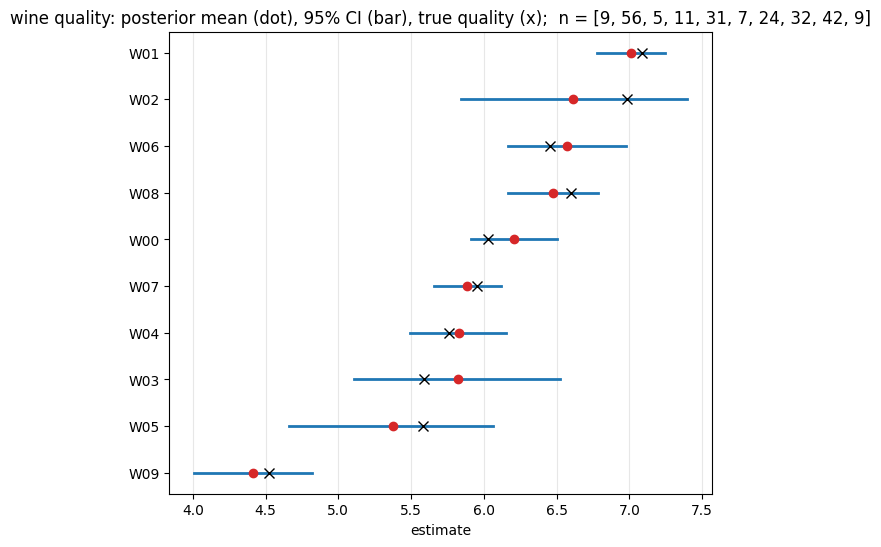

In [9]:
# Credible-interval ranking of wines with very uneven numbers of ratings.
wines = make_wine_ratings(n_wines=10, seed=11)
g = wines.groupby("wine")["rating"]
names = list(g.mean().index)
means = g.mean().to_numpy()
counts = g.count().to_numpy()
sems = g.std(ddof=1).fillna(1.0).to_numpy() / np.sqrt(counts)

shrunk, mu_hat, tau_hat = fit_partial_pooling_normal(means, sems)

# Posterior for each wine ~ Normal(shrunk_i, posterior_sd_i); sample for ranking.
post_sd = np.sqrt(1 / (1 / sems**2 + 1 / max(tau_hat, 1e-6) ** 2))
samples = [np.random.default_rng(i).normal(shrunk[i], post_sd[i], 4000)
           for i in range(len(names))]
truth = wines.groupby("wine")["true_quality"].first().to_numpy()

viz.plot_ranking_intervals(names, samples, truth=truth)
plt.title(f"wine quality: posterior mean (dot), 95% CI (bar), true quality (x);  n = {counts.tolist()}")
plt.show()

評価数の少ないワインは区間が長い = 「順位を断言できない」と正直に表示されます。
**順位の不確実性を見せる** ことが、平均点ランキングとの決定的な違いです
(LLM の評価スコア比較も同型 — §8)。

## 7. 応用 ④ ポーカー — 相手の 3-bet レンジをベイズ更新

相手がプリフロップで 3-bet する頻度 $\theta$ を、観測のたびに更新します。
事前は母集団傾向(平均 8% 前後)から。**30 ハンドしか見ていない相手** の
「3-bet 4 回(13%)」をどう解釈するかが shrinkage の実戦例です。

raw frequency        = 13.3%
posterior mean       = 10.7%   90% CI = [5.0%, 17.8%]
P(theta > 11%)       = 0.42  (is this an aggressive 3-bettor?)


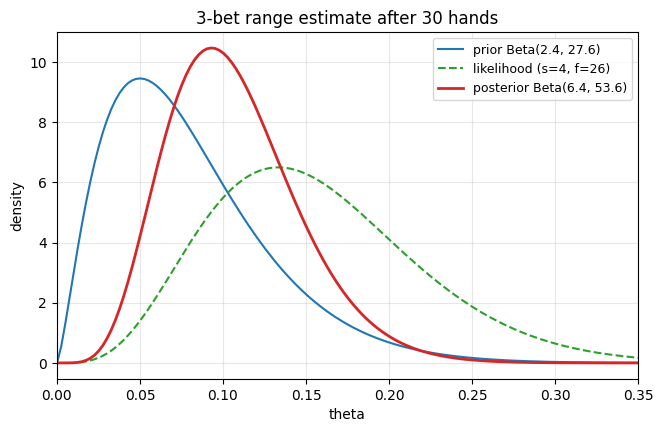

In [10]:
# Opponent 3-bet frequency: population prior + small sample of observations.
prior = BetaBinomial(2.4, 27.6)            # mean 8%, pseudo-sample 30 hands
obs_3bets, obs_opps = 4, 30                # 4 three-bets in 30 opportunities

post = prior.update(obs_3bets, obs_opps - obs_3bets)
lo, hi = post.credible_interval(0.9)
print(f"raw frequency        = {obs_3bets/obs_opps:.1%}")
print(f"posterior mean       = {post.mean:.1%}   90% CI = [{lo:.1%}, {hi:.1%}]")
print(f"P(theta > 11%)       = {1 - post.dist.cdf(0.11):.2f}  (is this an aggressive 3-bettor?)")

viz.plot_prior_likelihood_posterior(prior, obs_3bets, obs_opps - obs_3bets)
plt.title("3-bet range estimate after 30 hands")
plt.xlim(0, 0.35)
plt.show()

30 ハンドの 13% は「アグレッシブ確定」ではなく、事後平均は 10% 程度に縮みます。
GTO ソルバーに入れるレンジ推定の入力としても、点推定より分布の方が誠実です
(`gto` プロジェクトのレンジ推定と接続する話)。

## 8. 応用 ⑤ LLM 評価スコア — 合格率の差は本物か

2 つのプロンプト版でテストスイート(120 問)の合格率を比較。
これは A/B テストと完全に同型です — 合格率の差の分布と $P(\theta_B > \theta_A)$ を出します。

In [11]:
# LLM eval: pass rates on a 120-case suite, version A vs version B.
pass_a, n_cases = 87, 120
pass_b = 95

post_a = BetaBinomial(1, 1).update(pass_a, n_cases - pass_a)
post_b = BetaBinomial(1, 1).update(pass_b, n_cases - pass_b)
p_b_better = prob_a_beats_b(post_b, post_a, n=200_000)
diff = post_b.sample(100_000, seed=5) - post_a.sample(100_000, seed=6)
print(f"pass rates: A {pass_a}/{n_cases} = {pass_a/n_cases:.1%},  B {pass_b}/{n_cases} = {pass_b/n_cases:.1%}")
print(f"P(B better) = {p_b_better:.2f}")
print(f"95% CI for the improvement = [{np.quantile(diff, 0.025):+.1%}, {np.quantile(diff, 0.975):+.1%}]")
print("-> a 6.7pt gap on 120 cases is suggestive, NOT conclusive. Run more cases.")

pass rates: A 87/120 = 72.5%,  B 95/120 = 79.2%
P(B better) = 0.89
95% CI for the improvement = [-4.2%, +17.3%]
-> a 6.7pt gap on 120 cases is suggestive, NOT conclusive. Run more cases.


## 9. Failure Mode — 検証の落とし穴

- **PPC の検定統計量を 1 つしか見ない**: 平均は合うが裾が合わない、はよくある。
  複数の統計量(分散・最大値・ゼロ率)で見る。
- **LOO の Pareto-k 警告の無視**: 近似が壊れているサイン。該当点は本物の外れ値のことも多い。
- **ベイズファクターを漠然事前で使う**: 事前の幅がそのまま結論を動かす(Lindley)。
- **モデル選択 ≠ 真実の選択**: LOO が選ぶのは「予測が良いモデル」。
  因果や機構の正しさは別の問題。

## 10. まとめ

- **事前予測チェック**でモデルの常識を、**事後予測チェック**でデータ再現性を検査する。
- モデル比較は **LOO-CV(予測性能)** を軸に。ベイズファクターは事前への敏感さに注意。
- 応用 5 連発の共通パターン: **事後分布 → 確率・期待損失・信用区間つきランキング** へ変換し、
  そのまま意思決定に使う。点推定で要約するのは最後の最後でよい。

## 11. Exercises

1. §2 の PPC を「最大値」を統計量にしてやり直し、同じ結論になるか確かめよ。
2. §3 の比較に「2 次モデル」を加えて 3 モデルで LOO 比較せよ。
3. §4 の期待損失を「B を 10 倍のトラフィックで再テストした後」に再計算し、
   損失がどれだけ縮むか確認せよ。
4. §5 で観測期間を 4 年(1000 日)にすると $P(\mu > 0)$ はどうなるか。
5. §7 で 300 ハンド観測後(3-bet 40 回)の事後を計算し、30 ハンド時点と比較せよ。
6. (発展)§6 のランキングで「真の 1 位を当てる確率」を、
   生平均ランキングとベイズランキングで比較するシミュレーションを書け。

```{admonition} 実社会では
:class: important
事後分布は「点推定で潰す前に、意思決定の形に変換する」のが本領です。

- A/B テスト：$P(B>A)$ ＋**期待損失**で「許容劣化を下回ったら止める」。
- 投資・効果検証：年率 6% のドリフトも 1 年では符号すら不明 → 「何年分要るか」を逆算（autostock）。
- ランキング：評価数バラバラでも**信用区間つき順位**で「断言できない」を可視化（ワイン・LLM 評価・ポーカーのレンジ推定 gto）。
- モデル選択 ≠ 真実：LOO が選ぶのは予測が良いモデル。因果の正しさは別問題。
```